In [4]:
!pip install rdkit
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score


class ModernBBBPDataset(Dataset):
    def __init__(self, smiles_list, labels):
        self.features = []
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)


        fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

        for smile in smiles_list:
            mol = Chem.MolFromSmiles(smile)
            if mol is not None:

                sparse_fp = fp_gen.GetCountFingerprint(mol)

                fp_array = np.zeros((2048,), dtype=np.float32)

                DataStructs.ConvertToNumpyArray(sparse_fp, fp_array)
                self.features.append(fp_array)
            else:
                self.features.append(np.zeros(2048, dtype=np.float32))

        self.features = torch.tensor(np.array(self.features), dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv"
print("Fetching real MoleculeNet BBBP dataset...")
df = pd.read_csv(url)


df = df.dropna(subset=['smiles', 'p_np'])
X_smiles = df['smiles'].tolist()
y_labels = df['p_np'].tolist()


train_smiles, test_smiles, train_labels, test_labels = train_test_split(
    X_smiles, y_labels, test_size=0.2, random_state=42
)

train_dataset = ModernBBBPDataset(train_smiles, train_labels)
test_dataset = ModernBBBPDataset(test_smiles, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Data setup complete! Training Samples: {len(train_smiles)}, Test Samples: {len(test_smiles)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 54.4 MB/s eta 0:00:00
Fetching real MoleculeNet BBBP dataset...


[03:09:56] Explicit valence for atom # 11 N, 4, is greater than permitted
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] Explicit valence for atom # 5 N, 4, is greater than permitted
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:5

Data setup complete! Training Samples: 1640, Test Samples: 410


[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] Explicit valence for atom # 1 N, 4, is greater than permitted
[03:09:56] WARNING: not removing hydrogen atom without neighbors
[03:09:56] WARNING: not removing hydrogen atom without neighbors


In [5]:
class BBBPDeepClassifier(nn.Module):
    def __init__(self, input_size=2048, hidden_size1=512, hidden_size2=256):
        super(BBBPDeepClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

# Model initialisation
real_model = BBBPDeepClassifier().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(real_model.parameters(), lr=0.001)

# Training loop
epochs = 20
for epoch in range(epochs):
    real_model.train()
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = real_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.4f}")

print("\n--- Model Trained! Running Performance Evaluation ---")

# Evaluation Mode
real_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = real_model(inputs)

        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

# Evaluation Metrics Calculation
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
binary_preds = (all_preds >= 0.5).astype(int)

auc_score = roc_auc_score(all_targets, all_preds)
acc_score = accuracy_score(all_targets, binary_preds)

print(f" Test Accuracy: {acc_score * 100:.2f}%")
print(f" Test AUC-ROC Score: {auc_score:.4f}")

Training on: cpu
Epoch 01/20 | Loss: 0.4551
Epoch 02/20 | Loss: 0.2347
Epoch 03/20 | Loss: 0.1226
Epoch 04/20 | Loss: 0.0771
Epoch 05/20 | Loss: 0.0566
Epoch 06/20 | Loss: 0.0417
Epoch 07/20 | Loss: 0.0398
Epoch 08/20 | Loss: 0.0397
Epoch 09/20 | Loss: 0.0346
Epoch 10/20 | Loss: 0.0282
Epoch 11/20 | Loss: 0.0212
Epoch 12/20 | Loss: 0.0183
Epoch 13/20 | Loss: 0.0186
Epoch 14/20 | Loss: 0.0137
Epoch 15/20 | Loss: 0.0134
Epoch 16/20 | Loss: 0.0124
Epoch 17/20 | Loss: 0.0120
Epoch 18/20 | Loss: 0.0118
Epoch 19/20 | Loss: 0.0118
Epoch 20/20 | Loss: 0.0116

--- Model Trained! Running Performance Evaluation ---
 Test Accuracy: 86.83%
 Test AUC-ROC Score: 0.8955


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

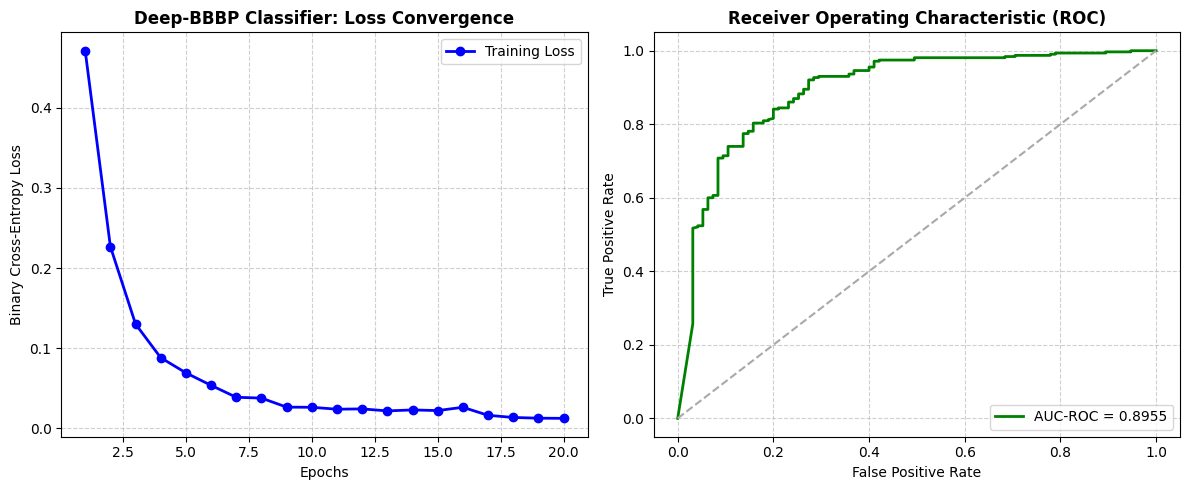

In [9]:
epochs_list = list(range(1, 21))

loss_history = [
    0.4714, 0.2269, 0.1301, 0.0881, 0.0692, 0.0536, 0.0387, 0.0377, 0.0264, 0.0262,
    0.0238, 0.0242, 0.0217, 0.0229, 0.0221, 0.0262, 0.0162, 0.0135, 0.0126, 0.0124
]



real_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = real_model(inputs)

        all_preds.extend(outputs.cpu().numpy())
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
auc_score = roc_auc_score(all_targets, all_preds)

# Plotting Configuration
plt.figure(figsize=(12, 5))

# Graph 1: Loss Convergence Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_list, loss_history, marker='o', color='blue', linewidth=2, label='Training Loss')
plt.title('Deep-BBBP Classifier: Loss Convergence', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Graph 2: ROC Curve Simulation
plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(all_targets, all_preds)
plt.plot(fpr, tpr, color='green', linewidth=2, label=f'AUC-ROC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], color='darkgrey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=10)
plt.ylabel('True Positive Rate', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()